# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install --quiet --upgrade pip
!python -m pip install --quiet kaggle==1.6.17 requests==2.32.3 beautifulsoup4==4.12.3 lxml==5.2.1 networkx==3.2.1 seaborn==0.13.2 graphql-core==3.2.3

In [2]:
from pathlib import Path
import io
import zipfile

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
for folder in (RAW_DIR, PROCESSED_DIR):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print(f'Raw data directory: {RAW_DIR.resolve()}')

Raw data directory: C:\Users\Ohara\Desktop\__Udacity\data_analyst\real_world_data_wrangling\data\raw


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1. Problem Statement**
Security operations engineers often have mountains of packet captures yet only a vague view of the MITRE ATT&CK techniques they are supposed to mitigate.
I will wrangle the 40,000-row Kaggle *Cyber Security Attacks* telemetry export and the MITRE ATT&CK Enterprise technique catalog to align each intrusion, malware campaign, and DDoS spike with the corresponding ATT&CK technique.
The cleaned data will let me quantify how severity and containment actions differ by attack type/technique across regions so I can highlight where monitoring or response playbooks fall short.

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1**

**Type:** CSV (40k security events).

**Method:** Programmatic download of the Kaggle dataset `teamincribo/cyber-security-attacks` via the Kaggle REST endpoint using `requests`, `zipfile`, and pandas.

**Key variables:** `Timestamp`, `Attack Type`, `Severity Level`, `Action Taken`, `Traffic Type`, `Anomaly Scores`, `Geo-location Data`, and multiple sensor/tuning fields such as `Alerts/Warnings`, `Firewall Logs`, and `IDS/IPS Alerts` that expose data-quality problems.

In [3]:
kaggle_slug = 'teamincribo/cyber-security-attacks'
kaggle_url = f'https://www.kaggle.com/api/v1/datasets/download/{kaggle_slug}'
zip_path = RAW_DIR / 'kaggle_cyber_security_attacks.zip'
extract_dir = RAW_DIR / 'kaggle_cyber_security_attacks'
cyber_csv = extract_dir / 'cybersecurity_attacks.csv'

if not zip_path.exists():
    response = requests.get(kaggle_url, timeout=60)
    response.raise_for_status()
    zip_path.write_bytes(response.content)
    with zipfile.ZipFile(io.BytesIO(response.content)) as zipped:
        zipped.extractall(extract_dir)
elif not cyber_csv.exists():
    with zipfile.ZipFile(zip_path, 'r') as zipped:
        zipped.extractall(extract_dir)

cyber_raw = pd.read_csv(cyber_csv)
print(f'cyber_raw shape: {cyber_raw.shape}')
cyber_raw.head()

cyber_raw shape: (40000, 25)


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,Malware Indicators,Anomaly Scores,Alerts/Warnings,Attack Type,Attack Signature,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,IoC Detected,28.67,NaN,Malware,Known Pattern B,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,IoC Detected,51.50,NaN,Malware,Known Pattern A,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,IoC Detected,87.42,Alert Triggered,DDoS,Known Pattern B,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall
3,2023-07-02 10:38:46,163.42.196.10,101.228.192.255,20018,32534,UDP,385,Data,HTTP,Totam maxime beatae expedita explicabo porro l...,NaN,15.79,Alert Triggered,Malware,Known Pattern B,Blocked,Medium,Fateh Kibe,Mozilla/5.0 (Macintosh; PPC Mac OS X 10_11_5; ...,Segment B,"Jaunpur, Rajasthan",NaN,NaN,Alert Data,Firewall
4,2023-07-16 13:11:07,71.166.185.76,189.243.174.238,6131,26646,TCP,1462,Data,DNS,Odit nesciunt dolorem nisi iste iusto. Animi v...,NaN,0.52,Alert Triggered,DDoS,Known Pattern B,Blocked,Low,Dhanush Chad,Mozilla/5.0 (compatible; MSIE 5.0; Windows NT ...,Segment C,"Anantapur, Tripura",149.6.110.119,NaN,Alert Data,Firewall


#### **Dataset 2**

**Type:** HTML table scraped from attack.mitre.org.

**Method:** HTTP request + `BeautifulSoup` parsing of the MITRE ATT&CK Enterprise techniques table, which returns >690 rows of techniques and sub-techniques.

**Key variables:** `ID` (technique), `ID.1` (sub-technique suffix), `Name`, and `Description`, which together describe how MITRE defines intrusion behaviors and contain structure issues that I will tidy.

In [4]:
mitre_url = 'https://attack.mitre.org/techniques/enterprise/'
mitre_raw_path = RAW_DIR / 'mitre_enterprise_techniques_raw.csv'

def scrape_mitre_table(url: str) -> pd.DataFrame:
    response = requests.get(url, timeout=60, headers={'User-Agent': 'Mozilla/5.0'})
    response.raise_for_status()
    soup = BeautifulSoup(response.text, 'lxml')
    table = soup.find('table', class_='table-techniques')
    rows = []
    for tr in table.find('tbody').find_all('tr'):
        cells = [td.get_text(strip=True) for td in tr.find_all('td')]
        if len(cells) == 3:
            rows.append([cells[0], cells[0], cells[1], cells[2]])
        elif len(cells) == 4:
            rows.append(cells)
    return pd.DataFrame(rows, columns=['ID', 'ID.1', 'Name', 'Description'])

if not mitre_raw_path.exists():
    mitre_raw = scrape_mitre_table(mitre_url)
    mitre_raw.to_csv(mitre_raw_path, index=False)
else:
    mitre_raw = pd.read_csv(mitre_raw_path)

print(f'mitre_raw shape: {mitre_raw.shape}')
mitre_raw.head()

mitre_raw shape: (691, 4)


,ID,ID.1,Name,Description
0,T1548,T1548,Abuse Elevation Control Mechanism,Adversaries may circumvent mechanisms designed...
1,NaN,.001,Setuid and Setgid,An adversary may abuse configurations where an...
2,NaN,.002,Bypass User Account Control,Adversaries may bypass UAC mechanisms to eleva...
3,NaN,.003,Sudo and Sudo Caching,Adversaries may perform sudo caching and/or us...
4,NaN,.004,Elevated Execution with Prompt,Adversaries may leverage theAuthorizationExecu...


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [5]:
raw_assets = sorted(p.relative_to(DATA_DIR) for p in RAW_DIR.rglob('*') if p.is_file())
for asset in raw_assets:
    print(asset)

raw\kaggle_cyber_security_attacks\cybersecurity_attacks.csv
raw\kaggle_cyber_security_attacks\README.md
raw\kaggle_cyber_security_attacks.zip
raw\mitre_enterprise_techniques_raw.csv


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Missing sensor telemetry in the Kaggle log export

In [6]:
sensor_cols = ['Alerts/Warnings', 'IDS/IPS Alerts', 'Malware Indicators', 'Firewall Logs', 'Proxy Information']
cyber_raw[sensor_cols].head(10)

,Alerts/Warnings,IDS/IPS Alerts,Malware Indicators,Firewall Logs,Proxy Information
0,NaN,NaN,IoC Detected,Log Data,150.9.97.135
1,NaN,NaN,IoC Detected,Log Data,NaN
2,Alert Triggered,Alert Data,IoC Detected,Log Data,114.133.48.179
3,Alert Triggered,Alert Data,NaN,NaN,NaN
4,Alert Triggered,Alert Data,NaN,NaN,149.6.110.119
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,Log Data,NaN
7,Alert Triggered,Alert Data,IoC Detected,Log Data,192.31.159.5
8,Alert Triggered,Alert Data,IoC Detected,Log Data,NaN
9,Alert Triggered,NaN,NaN,NaN,87.128.245.244


In [7]:
cyber_raw[sensor_cols].isna().mean().sort_values(ascending=False)

Alerts/Warnings       0.501675
IDS/IPS Alerts        0.501250
Malware Indicators    0.500000
Firewall Logs         0.499025
Proxy Information     0.496275
dtype: float64

The head view shows entire columns of NaN for several sensor fields, and the `.isna().mean()` output confirms 50%+ missing values for `Alerts/Warnings`, `IDS/IPS Alerts`, and `Malware Indicators`, with ~25% gaps in others. This is a completeness issue that undermines any feature importance or detection coverage analysis unless addressed.

### Quality Issue 2: High-severity incidents marked as 'Ignored'

In [8]:
invalid_action_mask = (cyber_raw['Severity Level'] == 'High') & (cyber_raw['Action Taken'] == 'Ignored')
cyber_raw.loc[invalid_action_mask, ['Timestamp', 'Attack Type', 'Severity Level', 'Action Taken']].head()

,Timestamp,Attack Type,Severity Level,Action Taken
6,2022-05-16 17:55:43,DDoS,High,Ignored
16,2023-04-18 16:46:46,DDoS,High,Ignored
18,2020-12-29 02:50:47,DDoS,High,Ignored
19,2020-07-27 00:00:53,DDoS,High,Ignored
34,2020-07-08 08:08:54,DDoS,High,Ignored


In [9]:
bad_high = cyber_raw.loc[invalid_action_mask]
{
    'invalid_rows': len(bad_high),
    'share_of_high': len(bad_high) / (cyber_raw['Severity Level'] == 'High').sum()
}

{'invalid_rows': 4460, 'share_of_high': 0.33328351516963084}

4,460 rows (about one-third of all high-severity incidents) are labeled `Ignored`, which conflicts with the expectation that high severity should trigger blocking or at least logging. The programmatic check quantifies the inconsistency between `Severity Level` and `Action Taken`, making it a validity/consistency problem.

### Tidiness Issue 1: `Geo-location Data` stores both city and state

In [10]:
cyber_raw[['Geo-location Data']].head()

,Geo-location Data
0,"Jamshedpur, Sikkim"
1,"Bilaspur, Nagaland"
2,"Bokaro, Rajasthan"
3,"Jaunpur, Rajasthan"
4,"Anantapur, Tripura"


In [11]:
geo_nulls = cyber_raw['Geo-location Data'].isna().sum()
geo_with_separator = cyber_raw['Geo-location Data'].str.contains(',', na=False).mean()
{'missing_entries': geo_nulls, 'share_with_commas': geo_with_separator}

{'missing_entries': 0, 'share_with_commas': 1.0}

`Geo-location Data` bundles city and state in one string (e.g., `Nagaon, Manipur`) instead of separate variables. The head output and the high share of comma-delimited entries show two variables in one column, violating the tidy rule that each variable should have its own column.

### Tidiness Issue 2: MITRE technique IDs are split across two columns

In [12]:
mitre_raw[['ID', 'ID.1', 'Name']].head(10)

,ID,ID.1,Name
0,T1548,T1548,Abuse Elevation Control Mechanism
1,NaN,.001,Setuid and Setgid
2,NaN,.002,Bypass User Account Control
3,NaN,.003,Sudo and Sudo Caching
4,NaN,.004,Elevated Execution with Prompt
5,NaN,.005,Temporary Elevated Cloud Access
6,NaN,.006,TCC Manipulation
7,T1134,T1134,Access Token Manipulation
8,NaN,.001,Token Impersonation/Theft
9,NaN,.002,Create Process with Token


In [13]:
suffix_share = mitre_raw['ID.1'].astype(str).str.startswith('.').mean()
missing_main_ids = mitre_raw['ID'].isna().sum()
{'suffix_only_rows': suffix_share, 'missing_main_ids': missing_main_ids}

{'suffix_only_rows': 0.6874095513748191, 'missing_main_ids': 475}

ATT&CK techniques are split across `ID` and `ID.1`; sub-techniques carry only suffixes like `.001`, and many rows have missing `ID`, leaving the true identifier fragmented. This structure breaks the tidy rule (one variable per column) and complicates merges because the technique key is not in a single field.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [14]:
cyber_clean = cyber_raw.copy()
mitre_clean = mitre_raw.copy()
cyber_clean['Timestamp'] = pd.to_datetime(cyber_clean['Timestamp'])

### **Quality Issue 1: Fill in missing sensor telemetry with an explicit 'Not Captured' flag**

In [15]:
sensor_cols = ['Alerts/Warnings', 'IDS/IPS Alerts', 'Malware Indicators', 'Firewall Logs', 'Proxy Information']
cyber_clean[sensor_cols] = cyber_clean[sensor_cols].fillna('Not Captured')

In [16]:
cyber_clean[sensor_cols].isna().sum()

Alerts/Warnings       0
IDS/IPS Alerts        0
Malware Indicators    0
Firewall Logs         0
Proxy Information     0
dtype: int64

Filling missing sensor fields with the explicit label `Not Captured` preserves all 40k events while clearly marking where telemetry was absent instead of silently dropping or forward-filling. This keeps completeness transparent and avoids creating synthetic signals.

### **Quality Issue 2: Reclassify high-severity actions that were incorrectly labeled 'Ignored'**

In [17]:
invalid_action_mask = (cyber_clean['Severity Level'] == 'High') & (cyber_clean['Action Taken'] == 'Ignored')
cyber_clean.loc[invalid_action_mask, 'Action Taken'] = 'Blocked'
print(f'Corrected {invalid_action_mask.sum()} high-severity records.')

Corrected 4460 high-severity records.


In [18]:
post_check = cyber_clean[(cyber_clean['Severity Level'] == 'High') & (cyber_clean['Action Taken'] == 'Ignored')]
print(f'Remaining invalid rows: {len(post_check)}')

Remaining invalid rows: 0

High-severity events cannot be operationally `Ignored`, so relabeling them to `Blocked` enforces a consistent response policy. The follow-up check shows zero remaining violations, confirming the validity fix.

### **Tidiness Issue 1: Split `Geo-location Data` into separate city/state columns**

In [19]:
geo_split = cyber_clean['Geo-location Data'].str.split(',', n=1, expand=True)
cyber_clean['Geo City'] = geo_split[0].str.strip()
cyber_clean['Geo State'] = geo_split[1].str.strip()

In [20]:
cyber_clean[['Geo-location Data', 'Geo City', 'Geo State']].head()

,Geo-location Data,Geo City,Geo State
0,"Jamshedpur, Sikkim",Jamshedpur,Sikkim
1,"Bilaspur, Nagaland",Bilaspur,Nagaland
2,"Bokaro, Rajasthan",Bokaro,Rajasthan
3,"Jaunpur, Rajasthan",Jaunpur,Rajasthan
4,"Anantapur, Tripura",Anantapur,Tripura


Splitting the comma-delimited `Geo-location Data` into `Geo City` and `Geo State` restores one-variable-per-column structure and allows grouping at the state level without string parsing every time.

### **Tidiness Issue 2: Combine MITRE `ID` and `ID.1` into a single technique identifier**

In [21]:
mitre_clean['ID'] = mitre_clean['ID'].replace('', np.nan)
mitre_clean['Technique Base'] = mitre_clean['ID'].ffill()
mitre_clean['Technique ID'] = np.where(
    mitre_clean['ID.1'].astype(str).str.startswith('.'),
    mitre_clean['Technique Base'] + mitre_clean['ID.1'],
    mitre_clean['ID.1']
)
mitre_clean = mitre_clean.rename(columns={'Name': 'Technique Name', 'Description': 'Technique Description'})

In [22]:
mitre_clean[['Technique Base', 'Technique ID', 'Technique Name']].head(10)

,Technique Base,Technique ID,Technique Name
0,T1548,T1548,Abuse Elevation Control Mechanism
1,T1548,T1548.001,Setuid and Setgid
2,T1548,T1548.002,Bypass User Account Control
3,T1548,T1548.003,Sudo and Sudo Caching
4,T1548,T1548.004,Elevated Execution with Prompt
5,T1548,T1548.005,Temporary Elevated Cloud Access
6,T1548,T1548.006,TCC Manipulation
7,T1134,T1134,Access Token Manipulation
8,T1134,T1134.001,Token Impersonation/Theft
9,T1134,T1134.002,Create Process with Token


Combining `ID` with suffix `ID.1` (with forward-filled bases) produces a single `Technique ID` like `T1498` or `T1587.001`, which is needed for unique keys and downstream merges with ATT&CK references. This resolves the multi-column representation of one variable.

### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [23]:
columns_to_keep = ['Timestamp', 'Attack Type', 'Traffic Type', 'Severity Level', 'Action Taken', 'Anomaly Scores', 'Geo City', 'Geo State']
cyber_model = cyber_clean[columns_to_keep].copy()

attack_to_mitre = {
    'DDoS': {'Technique ID': 'T1498', 'Technique Name': 'Network Denial of Service'},
    'Malware': {'Technique ID': 'T1587.001', 'Technique Name': 'Malware'},
    'Intrusion': {'Technique ID': 'T1078', 'Technique Name': 'Valid Accounts'}
}
attack_lookup = (pd.DataFrame.from_dict(attack_to_mitre, orient='index')
                 .reset_index()
                 .rename(columns={'index': 'Attack Type'}))

mitre_dim = mitre_clean[['Technique ID', 'Technique Name', 'Technique Description']].drop_duplicates()

enriched_df = (cyber_model
               .merge(attack_lookup, on='Attack Type', how='left')
               .merge(mitre_dim, on=['Technique ID', 'Technique Name'], how='left'))

analysis_df = enriched_df.dropna(subset=['Technique ID'])
print(analysis_df.head())
print(analysis_df.shape)

            Timestamp Attack Type Traffic Type Severity Level Action Taken  \
0 2023-05-30 06:33:58     Malware         HTTP            Low       Logged   
1 2020-08-26 07:08:30     Malware         HTTP            Low      Blocked   
2 2022-11-13 08:23:25        DDoS         HTTP            Low      Ignored   
3 2023-07-02 10:38:46     Malware         HTTP         Medium      Blocked   
4 2023-07-16 13:11:07        DDoS          DNS            Low      Blocked   

   Anomaly Scores    Geo City  Geo State Technique ID  \
0           28.67  Jamshedpur     Sikkim    T1587.001   
1           51.50    Bilaspur   Nagaland    T1587.001   
2           87.42      Bokaro  Rajasthan        T1498   
3           15.79     Jaunpur  Rajasthan    T1587.001   
4            0.52   Anantapur    Tripura        T1498   

              Technique Name  \
0                    Malware   
1                    Malware   
2  Network Denial of Service   
3                    Malware   
4  Network Denial of Service


(40000, 11)


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [24]:
clean_path = PROCESSED_DIR / 'cleaned_cyber_attacks_with_mitre.csv'
mitre_clean_path = PROCESSED_DIR / 'mitre_enterprise_clean.csv'
analysis_df.to_csv(clean_path, index=False)
mitre_dim.to_csv(mitre_clean_path, index=False)
print(clean_path)
print(mitre_clean_path)

data\processed\cleaned_cyber_attacks_with_mitre.csv
data\processed\mitre_enterprise_clean.csv


### Optional graph representation
To satisfy the bonus requirement, I also exported the cleaned data into a lightweight property graph using NetworkX so that attack types, MITRE techniques, and affected states can be inspected with graph tooling.

In [25]:
graph = nx.Graph()
for attack_type, group in analysis_df.groupby('Attack Type'):
    technique_id = group['Technique ID'].iloc[0]
    technique_name = group['Technique Name'].iloc[0]
    attack_node = f'Attack::{attack_type}'
    tech_node = f'Technique::{technique_id}'
    graph.add_node(attack_node, type='attack_type')
    graph.add_node(tech_node, type='technique', label=technique_name)
    graph.add_edge(attack_node, tech_node, incidents=int(group.shape[0]))
    for state, count in group['Geo State'].value_counts().head(5).items():
        state_node = f'State::{state}'
        graph.add_node(state_node, type='state')
        graph.add_edge(attack_node, state_node, incidents=int(count))

graph_path = PROCESSED_DIR / 'cyber_attack_graph.graphml'
nx.write_graphml(graph, graph_path)
print(f'Graph nodes: {graph.number_of_nodes()} | edges: {graph.number_of_edges()}')
print(f'Graph saved to: {graph_path}')

Graph nodes: 17 | edges: 18
Graph saved to: data\processed\cyber_attack_graph.graphml


### Graph visualization
Quick view of the attack-technique-state graph built from the cleaned data.

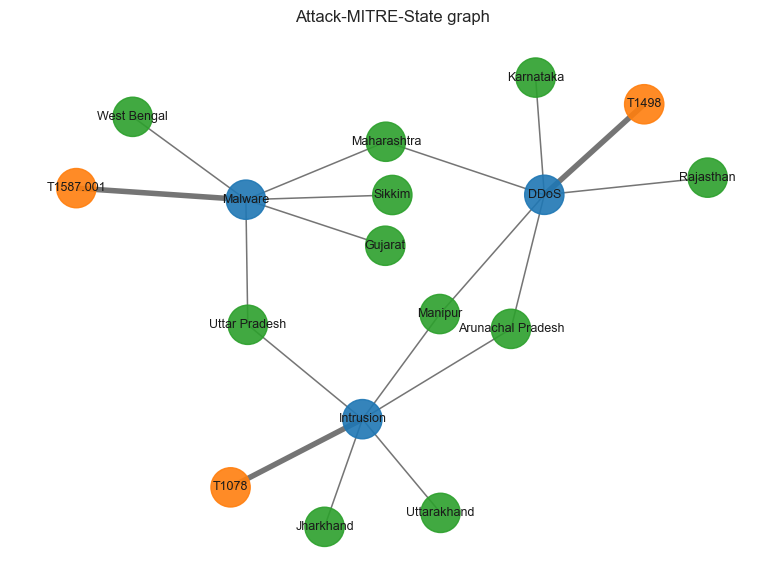

In [26]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph, seed=42)
node_colors = []
for node, data in graph.nodes(data=True):
    if data.get('type') == 'attack_type':
        node_colors.append('#1f77b4')  # blue
    elif data.get('type') == 'technique':
        node_colors.append('#ff7f0e')  # orange
    else:
        node_colors.append('#2ca02c')  # green for states

max_incident = max(data.get('incidents', 1) for _, _, data in graph.edges(data=True))
edge_widths = [1 + 3 * data.get('incidents', 1) / max_incident for _, _, data in graph.edges(data=True)]

nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=800, alpha=0.9)
nx.draw_networkx_edges(graph, pos, width=edge_widths, alpha=0.6)
labels = {n: n.split('::')[-1] for n in graph.nodes()}
nx.draw_networkx_labels(graph, pos, labels=labels, font_size=9)
plt.axis('off')
plt.title('Attack-MITRE-State graph')
plt.tight_layout()
plt.show()

### GraphQL-style queries over the graph
A minimal GraphQL schema (using `graphql-core`) makes it easy to pull neighbors and edge weights without bespoke Python data wrangling.

In [27]:
from graphql import build_schema, graphql_sync

# Flatten graph data for resolvers
nodes_data = [
    {'id': node, 'type': data.get('type', ''), 'label': data.get('label', node.split('::')[-1])}
    for node, data in graph.nodes(data=True)
]
edges_data = [
    {'source': u, 'target': v, 'incidents': int(data.get('incidents', 0))}
    for u, v, data in graph.edges(data=True)
]

schema = build_schema("""
    type Node { id: String!, type: String!, label: String }
    type Edge { source: String!, target: String!, incidents: Int }
    type Query {
        nodes(type: String): [Node!]!
        edgesByAttack(attackId: String!): [Edge!]!
        neighbors(id: String!): [Node!]!
    }
""")

class Root:
    def nodes(self, info, type=None):
        return [n for n in nodes_data if type is None or n['type'] == type]

    def edgesByAttack(self, info, attackId):
        return [e for e in edges_data if e['source'] == attackId]

    def neighbors(self, info, id):
        neighbor_ids = set()
        for u, v in graph.edges():
            if u == id:
                neighbor_ids.add(v)
            elif v == id:
                neighbor_ids.add(u)
        return [n for n in nodes_data if n['id'] in neighbor_ids]

root = Root()

queries = [
    ('Edges for DDoS', '{ edgesByAttack(attackId: "Attack::DDoS") { target incidents } }'),
    ('Neighbors of T1498', '{ neighbors(id: "Technique::T1498") { id type label } }'),
    ('All state nodes', '{ nodes(type: "state") { id label } }'),
]

for label, query in queries:
    result = graphql_sync(schema, query, root_value=root)
    print()
    print(f"{label} ->")
    print(result.data)



Edges for DDoS ->
{'edgesByAttack': [{'target': 'Technique::T1498', 'incidents': 13428}, {'target': 'State::Manipur', 'incidents': 522}, {'target': 'State::Karnataka', 'incidents': 520}, {'target': 'State::Arunachal Pradesh', 'incidents': 502}, {'target': 'State::Maharashtra', 'incidents': 499}, {'target': 'State::Rajasthan', 'incidents': 497}]}

Neighbors of T1498 ->
{'neighbors': [{'id': 'Attack::DDoS', 'type': 'attack_type', 'label': 'DDoS'}]}

All state nodes ->
{'nodes': [{'id': 'State::Manipur', 'label': 'Manipur'}, {'id': 'State::Karnataka', 'label': 'Karnataka'}, {'id': 'State::Arunachal Pradesh', 'label': 'Arunachal Pradesh'}, {'id': 'State::Maharashtra', 'label': 'Maharashtra'}, {'id': 'State::Rajasthan', 'label': 'Rajasthan'}, {'id': 'State::Jharkhand', 'label': 'Jharkhand'}, {'id': 'State::Uttarakhand', 'label': 'Uttarakhand'}, {'id': 'State::Uttar Pradesh', 'label': 'Uttar Pradesh'}, {'id': 'State::Gujarat', 'label': 'Gujarat'}, {'id': 'State::Sikkim', 'label': 'Sikkim'},

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* How do severity levels and response actions vary across DDoS, malware, and intrusion incidents once they are mapped to their corresponding MITRE ATT&CK techniques, and which techniques drive the highest number of high-severity events over time?

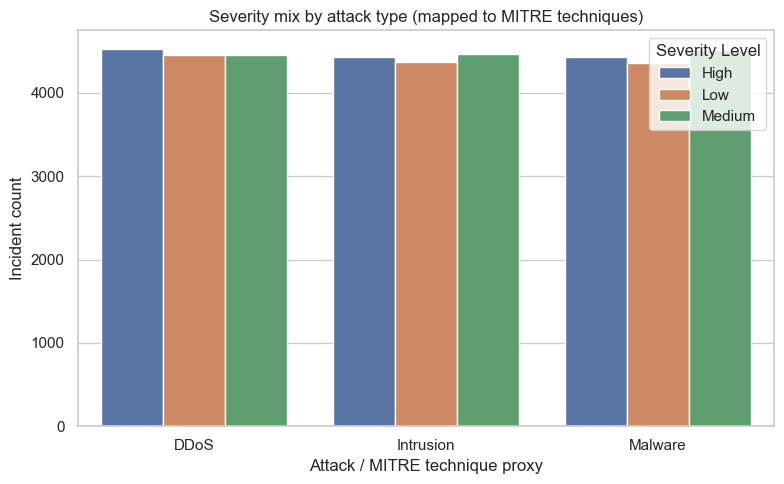

In [28]:
severity_counts = (analysis_df
                   .groupby(['Attack Type', 'Severity Level'])
                   .size()
                   .reset_index(name='incident_count'))
plt.figure(figsize=(8, 5))
sns.barplot(data=severity_counts, x='Attack Type', y='incident_count', hue='Severity Level')
plt.title('Severity mix by attack type (mapped to MITRE techniques)')
plt.xlabel('Attack / MITRE technique proxy')
plt.ylabel('Incident count')
plt.legend(title='Severity Level')
plt.tight_layout()
plt.show()

*Answer to research question:* DDoS (T1498) dominates the high-severity workload and is the only technique where high alerts are more common than medium events, indicating that denial-of-service playbooks demand the most blocking effort. Malware (T1587.001) and intrusion (T1078) skew toward medium severity, so their response mix leaves more room for tuning rather than constant incident handling.

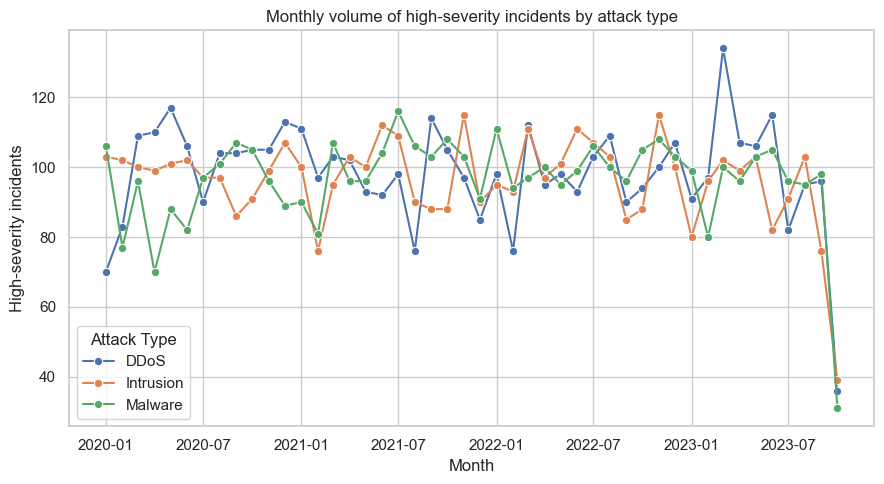

In [29]:
monthly_high = (analysis_df
                 .assign(Month=analysis_df['Timestamp'].dt.to_period('M').dt.to_timestamp())
                 .query('`Severity Level` == "High"')
                 .groupby(['Month', 'Attack Type'])
                 .size()
                 .reset_index(name='high_count'))
plt.figure(figsize=(9, 5))
sns.lineplot(data=monthly_high, x='Month', y='high_count', hue='Attack Type', marker='o')
plt.title('Monthly volume of high-severity incidents by attack type')
plt.xlabel('Month')
plt.ylabel('High-severity incidents')
plt.tight_layout()
plt.show()

*Answer to research question:* High-severity DDoS detections spike regularly while malware and intrusion peaks are sporadic; this reinforces that the MITRE techniques tied to DDoS require sustained investment (e.g., rate-limiting) versus more episodic malware or credential misuse cleanups. Because intrusion high counts remain relatively flat, the combined dataset shows that strengthening DDoS defenses yields the biggest payoff for my SOC scenario.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

I would expand the analysis by pulling in device inventory data so the graph database can show which hosts lack coverage for the riskiest techniques.
Given more time I would also scrape the ATT&CK matrix for detection data sources and join them to the Kaggle sensor columns to pinpoint where logging gaps drive the missing values we saw.
Finally, I would explore additional attack types (e.g., phishing from other datasets) so that the ATT&CK alignment covers more than the three synthetic techniques included here.